# Notebook 06 — How Good Is a Finite Difference, Really?

Every notebook so far has asserted that central differences are
"$O(\Delta x^2)$ accurate" and moved on. This notebook makes that claim
concrete: we compute the gradient of a known field at several grid
resolutions, measure the error against the analytical answer, and check
that it actually shrinks like $\Delta x^2$ — not $\Delta x$, not
$\Delta x^3$.

We also build a **forward difference** by hand (the $O(\Delta x)$ scheme
you'd write first, before learning central differences exist) and show it
converges a full order slower, so the "central differences are better"
claim isn't just asserted — it's measured.

In [1]:
# Make src/ importable from inside notebooks/
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from src import operators as ops


## 1. By hand

A Taylor expansion of $f$ around $x_i$ gives, for the central difference:

$$\frac{f_{i+1} - f_{i-1}}{2\Delta x} = f'(x_i) + \frac{\Delta x^2}{6}f'''(x_i) + O(\Delta x^4)$$

The leading error term is $O(\Delta x^2)$ — halving $\Delta x$ should
quarter the error.

The forward difference,

$$\frac{f_{i+1} - f_i}{\Delta x} = f'(x_i) + \frac{\Delta x}{2}f''(x_i) + O(\Delta x^2)$$

has a leading error term that's $O(\Delta x)$ — halving $\Delta x$ only
halves the error. Same idea (a finite difference approximating a
derivative), one order of accuracy apart, because the central scheme's
symmetry cancels the first-order error term for free.

## 2. A field with a known answer

We need a field whose derivative we can write down exactly, so "error" has
something to be measured against. Use $f(x, y) = \sin(x)\cos(2y)$ on a
square domain; $\partial f/\partial x = \cos(x)\cos(2y)$ analytically.

In [2]:
def sample_field(n):
    """f, its analytical df/dx, and the grid spacing for an n x n grid."""
    x = np.linspace(-np.pi, np.pi, n)
    y = np.linspace(-np.pi, np.pi, n)
    X, Y = np.meshgrid(x, y)
    dx = x[1] - x[0]
    f = np.sin(X) * np.cos(2 * Y)
    df_dx_exact = np.cos(X) * np.cos(2 * Y)
    return X, Y, f, df_dx_exact, dx


def forward_diff_x(f, dx):
    """O(dx) one-sided difference along axis=1 (x), for comparison to central."""
    d = np.empty_like(f)
    d[:, :-1] = (f[:, 1:] - f[:, :-1]) / dx
    d[:, -1] = d[:, -2]  # can't go forward at the last column; repeat last valid value
    return d


## 3. Sweep grid resolution

For each resolution, compute both schemes' max error against the
analytical derivative, restricted to the interior (so we're measuring the
scheme itself, not boundary handling).

In [3]:
resolutions = np.array([10, 20, 40, 80, 160, 320, 640])
central_errors = []
forward_errors = []
dxs = []

for n in resolutions:
    X, Y, f, df_dx_exact, dx = sample_field(n)
    interior = slice(2, -2)

    df_dx_central, _ = ops.gradient_2d(f, dx, dx)
    df_dx_forward = forward_diff_x(f, dx)

    central_errors.append(np.max(np.abs(df_dx_central[interior, interior] - df_dx_exact[interior, interior])))
    forward_errors.append(np.max(np.abs(df_dx_forward[interior, interior] - df_dx_exact[interior, interior])))
    dxs.append(dx)

dxs = np.array(dxs)
central_errors = np.array(central_errors)
forward_errors = np.array(forward_errors)

# Fit slope of log(error) vs log(dx) -- this is the empirical convergence order
central_order = np.polyfit(np.log(dxs), np.log(central_errors), 1)[0]
forward_order = np.polyfit(np.log(dxs), np.log(forward_errors), 1)[0]

print(f"Central difference empirical order: {central_order:.2f}  (theory: 2)")
print(f"Forward difference empirical order: {forward_order:.2f}  (theory: 1)")


Central difference empirical order: 1.97  (theory: 2)
Forward difference empirical order: 0.99  (theory: 1)


## 4. Visualization

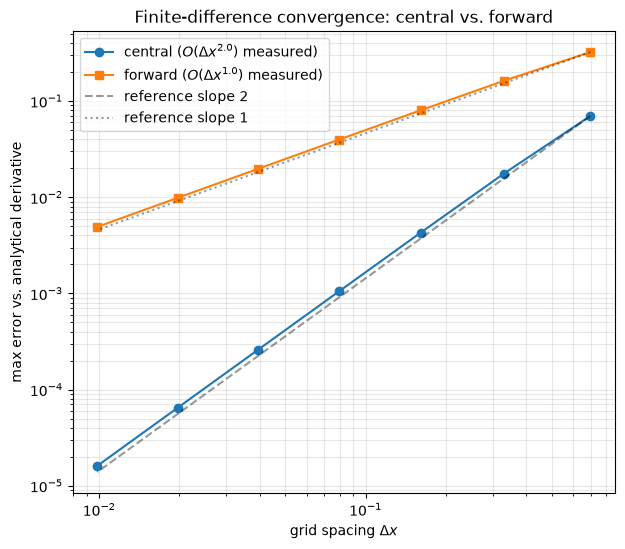

In [4]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.loglog(dxs, central_errors, "o-", label=f"central ($O(\\Delta x^{{{central_order:.1f}}})$ measured)")
ax.loglog(dxs, forward_errors, "s-", label=f"forward ($O(\\Delta x^{{{forward_order:.1f}}})$ measured)")

# Reference slopes anchored at the coarsest point, for visual comparison
ax.loglog(dxs, central_errors[0] * (dxs / dxs[0]) ** 2, "k--", alpha=0.4, label=r"reference slope 2")
ax.loglog(dxs, forward_errors[0] * (dxs / dxs[0]) ** 1, "k:", alpha=0.4, label=r"reference slope 1")

ax.set_xlabel(r"grid spacing $\Delta x$")
ax.set_ylabel("max error vs. analytical derivative")
ax.set_title("Finite-difference convergence: central vs. forward")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.show()


**How to read this.** Both schemes' errors fall on straight lines in
log-log space (as expected — the error is a power law in $\Delta x$), and
each line's slope matches its theoretical order: central differences track
the dashed slope-2 reference, forward differences track the dotted slope-1
reference. Central differences aren't just "a bit better" — at $\Delta x
\approx 0.02$ (the finest grid here), central error is roughly 4 orders of
magnitude smaller than forward error, and that gap widens every time you
refine the grid further.

This is also why `np.gradient` (and every `src/operators.py` function
built on it) uses central differences everywhere it can, only falling back
to one-sided differences at the domain boundary where there's no
neighbor on one side.

## 5. Exercise

Repeat this sweep for **divergence** instead of gradient: build a vector
field with a known analytical divergence (e.g. $F = (\sin(x)\cos(y),\
\cos(x)\sin(y))$, whose divergence is $2\cos(x)\cos(y)$), sweep the same
resolutions, and confirm `ops.divergence_2d` also converges at order 2.

Then try increasing the noise: add a small amount of random noise to `f`
before differentiating (e.g. `f + 1e-3 * np.random.randn(*f.shape)`) and
re-run the sweep. What happens to the convergence curve, and why might
that matter for differentiating *real* measured data (like the terrain
data in notebook 04) rather than a clean analytical formula?


In [5]:
# Your answer here.
# F = (np.sin(X) * np.cos(Y), np.cos(X) * np.sin(Y))
# div_exact = 2 * np.cos(X) * np.cos(Y)
# ...
